In [2]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-03-03 04:36:36--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-03 04:36:36--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-03 04:36:37--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [3]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 32.6 MB/s eta 0:00:00


# Model Performance Stall – Problem Analysis & Solutions (To-the-Point Report)

## 1. Core Problem

The model performance is stalling (~0.20–0.24 Spearman) despite architecture tuning (RNN/GRU, pooling, hyperparameters). The issue is **not model capacity**, but **task misalignment and unused dataset structure**.

---

# 2. Key Problems Identified

## Problem 1: Task Formulation Mismatch

* Dataset structure:

  * 1140 story setups
  * Exactly 2 meanings per setup
  * Mean absolute label gap ≈ 1.83
  * 792/1140 pairs differ by > 1.0

* Interpretation:
  The task is fundamentally **comparative (ranking)** per story.

* Current approach:
  Pure regression (Huber loss) treating each sample independently.

* Issue:
  Model is not explicitly learning
  **“Which meaning is more plausible for this story?”**

---

## Problem 2: Loss–Metric Misalignment

* Training loss: Huber (regression-focused)
* Leaderboard metric: Spearman correlation + within-std accuracy

Spearman evaluates **ranking consistency**, not numeric closeness.

Current hyperparameter tuning optimizes regression loss,
but evaluation rewards ranking quality.

→ Optuna is tuning the wrong objective.

---

## Problem 3: Unused Strong Signals

The following fields are ignored:

* `choices` (annotator distribution)
* `nonsensical` count
* `homonym`
* ending-present flag

These contain **direct plausibility information**, but the model only uses mean score and text embeddings.

Information loss reduces performance ceiling.

---

## Problem 4: Weak Representation Strategy

* Using limited pooling (e.g., last hidden state)
* No explicit interaction features
* No overlap features between story and meaning

The model must infer everything from embeddings alone, increasing learning difficulty.

---

## Problem 5: Validation Leakage Risk

Without grouped cross-validation:

* One meaning of a story may appear in train
* The other meaning appears in validation

This causes leakage and unstable validation estimates.

---

# 3. Proposed Solutions (Priority Order)

## 1. Metric-Aligned Optimization

Change Optuna objective to:

score = Spearman − α * MAE
Maximize score

This aligns hyperparameter search with leaderboard metric.

---

## 2. Add Auxiliary Pairwise Ranking Loss

For each setup:

* Compute prediction difference between two meanings
* Enforce correct ordering using ranking loss

Final loss:

Total Loss = Huber + λ × Ranking Loss

Effect:

* Directly improves ordering within each story
* Boosts Spearman significantly

---

## 3. Train on Annotator Distribution

Instead of only mean score:

* Use full 5-rating distribution as soft target
* Keep Huber on mean as auxiliary

This captures uncertainty and disagreement structure.

---

## 4. Add Small Meta / Numeric Features

Include in prediction head:

* nonsensical_count
* homonym embedding/id
* ending-present flag
* cosine overlap (story vs meaning)

Low complexity, high signal gain.

---

## 5. Improve Pooling Strategy

Use:

Concatenation of:

* Mean pooling
* Max pooling
* Last hidden state

Improves representation richness without increasing model complexity.

---

## 6. Grouped Cross-Validation

Group splits by setup or homonym.

Prevents leakage and provides realistic validation performance.

---

## 7. Post-Hoc Calibration

Apply isotonic or linear rescaling on validation predictions before clipping to [1,5].

Small but consistent Spearman improvement.

---



# 5. Conclusion

The model stalls because:

* The problem is treated as pure regression
* Ranking structure is ignored
* Strong auxiliary signals are unused
* Optimization objective does not match evaluation metric

The solution is **task-aware reformulation**, not heavier architecture.

Main shift:

From
Generic regression model

To
Metric-aligned, pairwise-aware structured learning.


In [4]:
import json
import os
import random
from contextlib import nullcontext

import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.stats import spearmanr
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from torch.utils.data import DataLoader, Dataset, Sampler


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


TRAIN_JSON = "/content/train.json"
TEST_JSON = "/content/test.json"
GLOVE_PATH = "/content/glove.6B.100d.txt"

MAX_WORDS = 10000
MAX_LEN = 150
EMBED_DIM = 100

TUNE_EPOCHS = 18
FINAL_EPOCHS = 36
PATIENCE = 5
N_TRIALS = 35


if not os.path.exists(TRAIN_JSON):
    raise FileNotFoundError(f"Missing {TRAIN_JSON}")
if not os.path.exists(TEST_JSON):
    raise FileNotFoundError(f"Missing {TEST_JSON}")
if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")


def build_story(item):
    return " ".join([
        item.get("precontext", ""),
        item.get("sentence", ""),
        item.get("ending", ""),
    ])


def build_meaning(item):
    return item.get("judged_meaning", "")


def build_setup_key(item):
    return "|||".join([
        item.get("precontext", ""),
        item.get("sentence", ""),
        item.get("ending", ""),
    ])


def get_amp_autocast(device):
    if device.type != "cuda":
        return nullcontext()
    if hasattr(torch, "autocast"):
        return torch.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)


def get_grad_scaler(device):
    amp_enabled = device.type == "cuda"
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        return torch.amp.GradScaler(device.type, enabled=amp_enabled)
    return torch.cuda.amp.GradScaler(enabled=amp_enabled)


with open(TRAIN_JSON, encoding="utf8") as f:
    raw_train = json.load(f)

train_items = list(raw_train.values())
stories = [build_story(i) for i in train_items]
meanings = [build_meaning(i) for i in train_items]
labels = np.array([i["average"] for i in train_items], dtype=np.float32)
stdevs = np.array([i["stdev"] for i in train_items], dtype=np.float32)

setup_keys = [build_setup_key(i) for i in train_items]
unique_setup = {k: idx for idx, k in enumerate(sorted(set(setup_keys)))}
setup_ids = np.array([unique_setup[k] for k in setup_keys], dtype=np.int64)

homonyms = [i.get("homonym", "<UNK>") for i in train_items]
unique_hom = {h: idx for idx, h in enumerate(sorted(set(homonyms)), start=1)}
hom_ids = np.array([unique_hom.get(h, 0) for h in homonyms], dtype=np.int64)

nons_count = np.array(
    [sum(1 for v in i.get("nonsensical", []) if v) for i in train_items],
    dtype=np.float32,
)
ending_flag = np.array(
    [1.0 if len(i.get("ending", "").strip()) > 0 else 0.0 for i in train_items],
    dtype=np.float32,
)
meta_feats = np.stack([
    np.clip(nons_count / 5.0, 0.0, 1.0),
    ending_flag,
], axis=1).astype(np.float32)


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(stories + meanings)

X_story = pad_sequences(tokenizer.texts_to_sequences(stories), maxlen=MAX_LEN, padding="post")
X_mean = pad_sequences(tokenizer.texts_to_sequences(meanings), maxlen=MAX_LEN, padding="post")

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(X_story, labels, groups=setup_ids))

Xs_train, Xs_val = X_story[train_idx], X_story[val_idx]
Xm_train, Xm_val = X_mean[train_idx], X_mean[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]
s_train, s_val = stdevs[train_idx], stdevs[val_idx]
setup_train, setup_val = setup_ids[train_idx], setup_ids[val_idx]
hom_train, hom_val = hom_ids[train_idx], hom_ids[val_idx]
meta_train, meta_val = meta_feats[train_idx], meta_feats[val_idx]


embeddings_index = {}
with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        vals = line.split()
        embeddings_index[vals[0]] = np.asarray(vals[1:], dtype="float32")

word_index = tokenizer.word_index
num_words = min(MAX_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBED_DIM), dtype=np.float32)
for word, idx in word_index.items():
    if idx < num_words and word in embeddings_index:
        embedding_matrix[idx] = embeddings_index[word]


class AmbiStoryDataset(Dataset):
    def __init__(self, X_story, X_mean, labels, stdevs, setup_ids, hom_ids, meta_feats):
        self.X_story = torch.tensor(X_story, dtype=torch.long)
        self.X_mean = torch.tensor(X_mean, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.stdevs = torch.tensor(stdevs, dtype=torch.float32)
        self.setup_ids = torch.tensor(setup_ids, dtype=torch.long)
        self.hom_ids = torch.tensor(hom_ids, dtype=torch.long)
        self.meta = torch.tensor(meta_feats, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.X_story[idx],
            self.X_mean[idx],
            self.labels[idx],
            self.stdevs[idx],
            self.setup_ids[idx],
            self.hom_ids[idx],
            self.meta[idx],
        )


class SetupBatchSampler(Sampler):
    def __init__(self, setup_ids, setups_per_batch=8, shuffle=True):
        self.shuffle = shuffle
        self.setups_per_batch = setups_per_batch
        self.indices_by_setup = {}
        for idx, sid in enumerate(setup_ids):
            self.indices_by_setup.setdefault(int(sid), []).append(idx)
        self.setup_keys = list(self.indices_by_setup.keys())

    def __iter__(self):
        keys = self.setup_keys.copy()
        if self.shuffle:
            random.shuffle(keys)

        for start in range(0, len(keys), self.setups_per_batch):
            selected = keys[start:start + self.setups_per_batch]
            batch = []
            for sid in selected:
                inds = self.indices_by_setup[sid]
                if self.shuffle:
                    random.shuffle(inds)
                batch.extend(inds)
            if batch:
                yield batch

    def __len__(self):
        return (len(self.setup_keys) + self.setups_per_batch - 1) // self.setups_per_batch


class BiGRUEncoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix, rnn_units, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=rnn_units,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        out, _ = self.gru(x)
        mean_pool = out.mean(dim=1)
        max_pool = out.max(dim=1).values
        return torch.cat([mean_pool, max_pool], dim=1)


class DualEncoderModel(nn.Module):
    def __init__(
        self,
        num_words,
        embed_dim,
        embedding_matrix,
        rnn_units,
        num_layers,
        dropout,
        dense_units,
        hom_vocab_size,
        hom_emb_dim,
        meta_dim,
    ):
        super().__init__()
        encoder_args = (num_words, embed_dim, embedding_matrix, rnn_units, num_layers, dropout)
        self.story_encoder = BiGRUEncoder(*encoder_args)
        self.meaning_encoder = BiGRUEncoder(*encoder_args)

        self.hom_emb = nn.Embedding(hom_vocab_size + 1, hom_emb_dim)

        base_dim = rnn_units * 4
        combined_dim = (base_dim * 4) + 1 + hom_emb_dim + meta_dim

        self.head = nn.Sequential(
            nn.Linear(combined_dim, dense_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_units, 1),
        )

    def forward(self, story, meaning, hom_ids, meta):
        sv = self.story_encoder(story)
        mv = self.meaning_encoder(meaning)
        abs_diff = torch.abs(sv - mv)
        prod = sv * mv
        cosine = F.cosine_similarity(sv, mv, dim=1, eps=1e-8).unsqueeze(1)
        hom_vec = self.hom_emb(hom_ids)

        combined = torch.cat([sv, mv, abs_diff, prod, cosine, hom_vec, meta], dim=1)
        return self.head(combined).squeeze(1)


def pairwise_setup_ranking_loss(preds, targets, setup_ids, margin=0.2):
    total_loss = preds.new_tensor(0.0)
    groups = 0

    unique_setups = torch.unique(setup_ids)
    for sid in unique_setups:
        mask = setup_ids == sid
        p = preds[mask]
        y = targets[mask]
        if p.numel() < 2:
            continue

        y_diff = y.unsqueeze(1) - y.unsqueeze(0)
        p_diff = p.unsqueeze(1) - p.unsqueeze(0)
        valid = y_diff.abs() > 1e-6
        if valid.sum() == 0:
            continue

        loss_mat = torch.relu(margin - y_diff.sign() * p_diff)
        total_loss = total_loss + (loss_mat * valid).sum() / valid.sum()
        groups += 1

    if groups == 0:
        return preds.new_tensor(0.0)
    return total_loss / groups


def create_loaders(batch_size_setups):
    workers = 2 if device.type == "cuda" else 0

    train_ds = AmbiStoryDataset(Xs_train, Xm_train, y_train, s_train, setup_train, hom_train, meta_train)
    val_ds = AmbiStoryDataset(Xs_val, Xm_val, y_val, s_val, setup_val, hom_val, meta_val)

    train_sampler = SetupBatchSampler(setup_train, setups_per_batch=batch_size_setups, shuffle=True)

    train_loader = DataLoader(
        train_ds,
        batch_sampler=train_sampler,
        pin_memory=(device.type == "cuda"),
        num_workers=workers,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        pin_memory=(device.type == "cuda"),
        num_workers=workers,
    )
    return train_loader, val_loader


def train_one_epoch(model, loader, optimizer, scaler, huber_loss_fn, rank_lambda, rank_margin):
    model.train()
    total_loss = 0.0

    for story, meaning, label, _stdev, sid, hom, meta in loader:
        story = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)
        sid = sid.to(device, non_blocking=True)
        hom = hom.to(device, non_blocking=True)
        meta = meta.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_amp_autocast(device):
            preds = model(story, meaning, hom, meta)
            huber = huber_loss_fn(preds, label)
            rank = pairwise_setup_ranking_loss(preds, label, sid, margin=rank_margin)
            loss = huber + rank_lambda * rank

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate_epoch(model, loader, huber_loss_fn):
    model.eval()
    total_loss = 0.0

    for story, meaning, label, _stdev, _sid, hom, meta in loader:
        story = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)
        hom = hom.to(device, non_blocking=True)
        meta = meta.to(device, non_blocking=True)

        preds = model(story, meaning, hom, meta)
        total_loss += huber_loss_fn(preds, label).item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def predict(model, Xs, Xm, hom_ids_arr, meta_arr):
    model.eval()
    dummy_y = np.zeros(len(Xs), dtype=np.float32)
    dummy_s = np.ones(len(Xs), dtype=np.float32)
    dummy_sid = np.arange(len(Xs), dtype=np.int64)

    ds = AmbiStoryDataset(Xs, Xm, dummy_y, dummy_s, dummy_sid, hom_ids_arr, meta_arr)
    loader = DataLoader(ds, batch_size=64, shuffle=False, pin_memory=(device.type == "cuda"))

    all_preds = []
    for story, meaning, _label, _stdev, _sid, hom, meta in loader:
        story = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        hom = hom.to(device, non_blocking=True)
        meta = meta.to(device, non_blocking=True)
        preds = model(story, meaning, hom, meta)
        all_preds.append(preds.cpu().numpy())

    return np.clip(np.concatenate(all_preds), 1, 5)


def objective_score(y_true, y_pred, s_true):
    sp = spearmanr(y_true, y_pred).correlation
    if np.isnan(sp):
        sp = -1.0
    acc = np.mean(np.abs(y_pred - y_true) <= np.maximum(s_true, 1.0))
    mae = np.mean(np.abs(y_pred - y_true))
    return float(sp + 0.25 * acc - 0.05 * mae), float(sp), float(acc), float(mae)


def run_training(params, epochs, patience, trial=None):
    model = DualEncoderModel(
        num_words=num_words,
        embed_dim=EMBED_DIM,
        embedding_matrix=embedding_matrix,
        rnn_units=params["rnn_units"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        dense_units=params["dense_units"],
        hom_vocab_size=len(unique_hom),
        hom_emb_dim=params["hom_emb_dim"],
        meta_dim=meta_train.shape[1],
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
    scaler = get_grad_scaler(device)
    huber_loss_fn = nn.HuberLoss(reduction="mean", delta=1.0)

    train_loader, val_loader = create_loaders(params["setup_batch"])

    best_score = -1e9
    best_weights = None
    patience_ctr = 0

    for epoch in range(1, epochs + 1):
        _ = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            huber_loss_fn,
            rank_lambda=params["rank_lambda"],
            rank_margin=params["rank_margin"],
        )

        val_preds = predict(model, Xs_val, Xm_val, hom_val, meta_val)
        score, sp, acc, mae = objective_score(y_val, val_preds, s_val)
        scheduler.step(score)

        if trial is not None:
            trial.report(score, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if score > best_score:
            best_score = score
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_weights is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

    final_preds = predict(model, Xs_val, Xm_val, hom_val, meta_val)
    score, sp, acc, mae = objective_score(y_val, final_preds, s_val)
    return model, score, sp, acc, mae


def objective(trial):
    params = {
        "rnn_units": trial.suggest_categorical("rnn_units", [64, 96, 128]),
        "num_layers": trial.suggest_categorical("num_layers", [1, 2]),
        "dropout": trial.suggest_float("dropout", 0.15, 0.45),
        "dense_units": trial.suggest_categorical("dense_units", [96, 128, 192, 256]),
        "hom_emb_dim": trial.suggest_categorical("hom_emb_dim", [8, 16, 24]),
        "lr": trial.suggest_float("lr", 1e-4, 2e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 5e-4, log=True),
        "setup_batch": trial.suggest_categorical("setup_batch", [6, 8, 10, 12]),
        "rank_lambda": trial.suggest_float("rank_lambda", 0.2, 0.9),
        "rank_margin": trial.suggest_float("rank_margin", 0.1, 0.6),
    }

    _, score, _, _, _ = run_training(params, epochs=TUNE_EPOCHS, patience=PATIENCE, trial=trial)
    return score


def make_test_meta_and_hom(test_items):
    test_hom = np.array([unique_hom.get(i.get("homonym", "<UNK>"), 0) for i in test_items], dtype=np.int64)
    test_nons = np.array([sum(1 for v in i.get("nonsensical", []) if v) for i in test_items], dtype=np.float32)
    test_end = np.array([1.0 if len(i.get("ending", "").strip()) > 0 else 0.0 for i in test_items], dtype=np.float32)
    test_meta = np.stack([np.clip(test_nons / 5.0, 0.0, 1.0), test_end], axis=1).astype(np.float32)
    return test_hom, test_meta


def main():
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=5)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print("\nBest trial:")
    print(f"  Value (composite): {study.best_value:.5f}")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    best_model, _, val_sp, val_acc, val_mae = run_training(
        study.best_params,
        epochs=FINAL_EPOCHS,
        patience=7,
        trial=None,
    )

    print("\nValidation with best params:")
    print("Spearman r           :", val_sp)
    print("Accuracy within std  :", val_acc)
    print("MAE                  :", val_mae)

    with open(TEST_JSON, encoding="utf8") as f:
        raw_test = json.load(f)

    test_items = list(raw_test.values())
    test_story = pad_sequences(
        tokenizer.texts_to_sequences([build_story(i) for i in test_items]),
        maxlen=MAX_LEN,
        padding="post",
    )
    test_mean = pad_sequences(
        tokenizer.texts_to_sequences([build_meaning(i) for i in test_items]),
        maxlen=MAX_LEN,
        padding="post",
    )
    test_hom, test_meta = make_test_meta_and_hom(test_items)

    test_preds = predict(best_model, test_story, test_mean, test_hom, test_meta)
    print("\nSample Test Predictions:")
    for i in range(min(10, len(test_preds))):
        print(f"Sample {i+1}: {test_preds[i]:.3f}")

    os.makedirs("/content", exist_ok=True)
    with open("/content/try_mod_best_params.json", "w", encoding="utf8") as f:
        json.dump(study.best_params, f, indent=2)

    torch.save(
        {
            "state_dict": best_model.state_dict(),
            "best_params": study.best_params,
            "num_words": num_words,
            "embed_dim": EMBED_DIM,
            "hom_vocab_size": len(unique_hom),
        },
        "/content/try_mod_best_model.pt",
    )

    np.savez(
        "/content/try_mod_val_data.npz",
        Xs_val=Xs_val,
        Xm_val=Xm_val,
        y_val=y_val,
        s_val=s_val,
        hom_val=hom_val,
        meta_val=meta_val,
    )

    np.save("/content/try_mod_test_preds.npy", test_preds)

    print("\nSaved:")
    print("  /content/try_mod_best_params.json")
    print("  /content/try_mod_best_model.pt")
    print("  /content/try_mod_val_data.npz")
    print("  /content/try_mod_test_preds.npy")


if __name__ == "__main__":
    main()


Using device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


[I 2026-03-03 11:06:24,519] A new study created in memory with name: no-name-00b51fe2-168d-4719-9852-b5f9724d79e6


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2026-03-03 11:07:14,457] Trial 0 finished with value: 0.5058483417101028 and parameters: {'rnn_units': 96, 'num_layers': 1, 'dropout': 0.1967983561008608, 'dense_units': 128, 'hom_emb_dim': 16, 'lr': 0.00018891200276189413, 'weight_decay': 3.0955664602423687e-06, 'setup_batch': 10, 'rank_lambda': 0.40386039813862934, 'rank_margin': 0.40592644736118977}. Best is trial 0 with value: 0.5058483417101028.
[I 2026-03-03 11:08:05,059] Trial 1 finished with value: 0.5773048052043268 and parameters: {'rnn_units': 128, 'num_layers': 2, 'dropout': 0.20990213464750793, 'dense_units': 256, 'hom_emb_dim': 24, 'lr': 0.0018043311207136257, 'weight_decay': 0.00015199881220083957, 'setup_batch': 10, 'rank_lambda': 0.2854267643913452, 'rank_margin': 0.34758845505563507}. Best is trial 1 with value: 0.5773048052043268.
[I 2026-03-03 11:08:44,344] Trial 2 finished with value: 0.7153413018926619 and parameters: {'rnn_units': 96, 'num_layers': 1, 'dropout': 0.30602040635334327, 'dense_units': 192, 'hom_em

In [1]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-03-03 11:01:17--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-03 11:01:17--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-03 11:01:18--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 34.3 MB/s eta 0:00:00


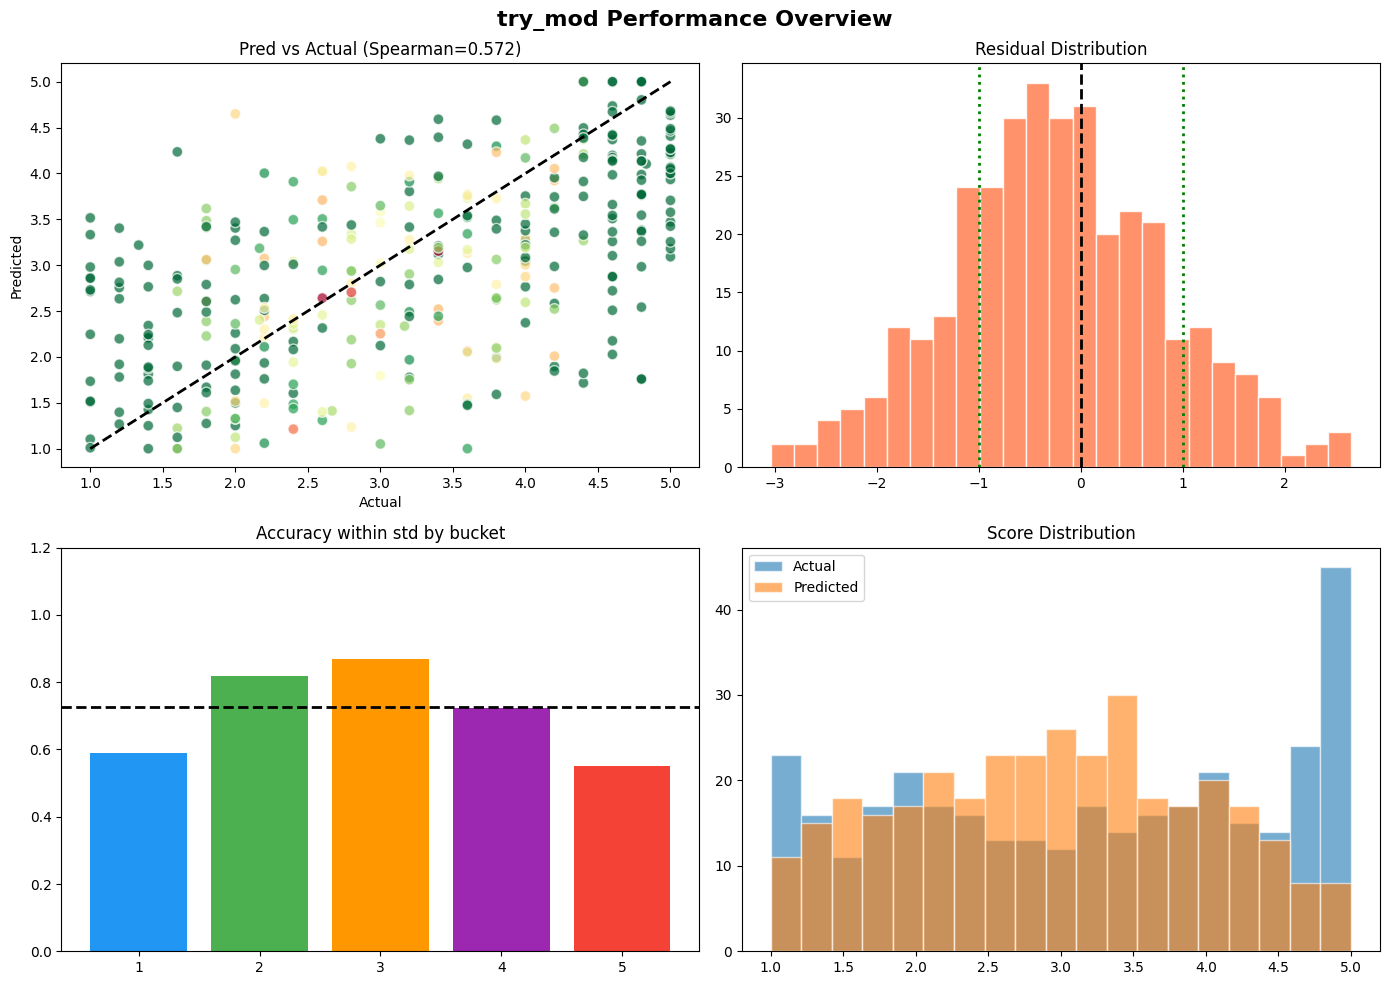

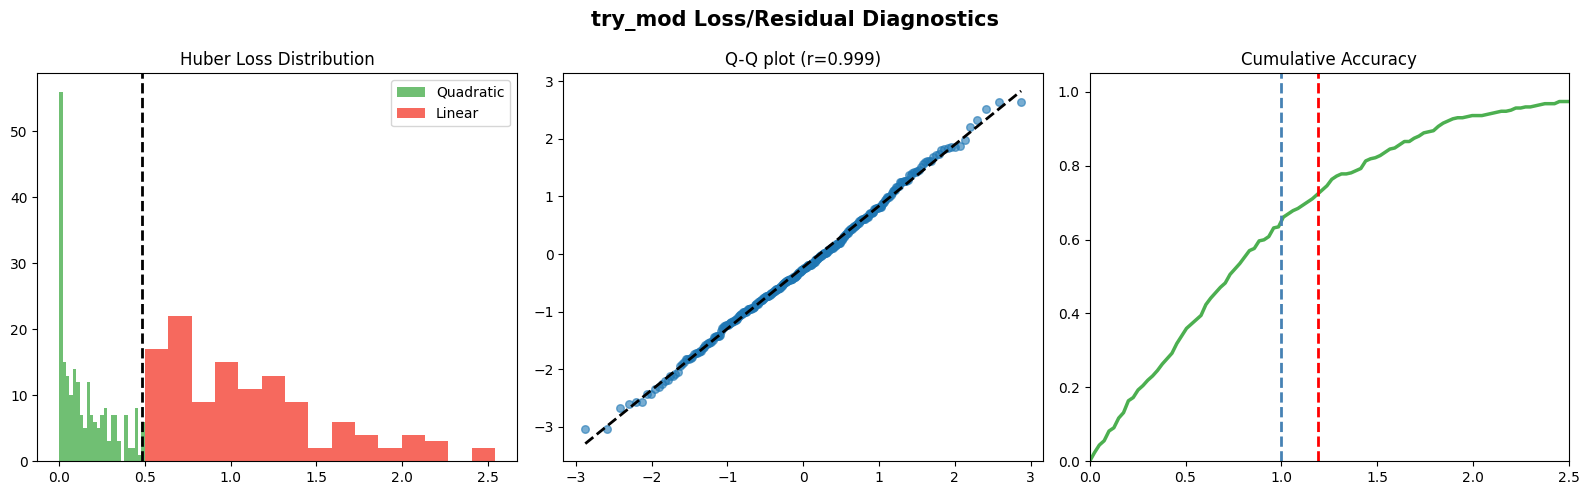


Validation metrics:
Spearman r           : 0.5724361756305022
Accuracy within std  : 0.7251461988304093
MAE                  : 0.8667621
Mean Huber Loss      : 0.48464137

Saved:
  /content/try_mod_overview.png
  /content/try_mod_diagnostics.png


In [5]:
# ============================================================
# Visualization — try_mod (PyTorch BiGRU + interactions)
# Works with either:
#   A) in-memory variables (model, Xs_val, Xm_val, y_val, s_val, hom_val, meta_val)
#   B) saved artifacts from try_mod.py in /content
# ============================================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr


DELTA = 1.0


class BiGRUEncoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix, rnn_units, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=rnn_units,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        out, _ = self.gru(x)
        mean_pool = out.mean(dim=1)
        max_pool = out.max(dim=1).values
        return torch.cat([mean_pool, max_pool], dim=1)


class DualEncoderModel(nn.Module):
    def __init__(
        self,
        num_words,
        embed_dim,
        embedding_matrix,
        rnn_units,
        num_layers,
        dropout,
        dense_units,
        hom_vocab_size,
        hom_emb_dim,
        meta_dim,
    ):
        super().__init__()
        encoder_args = (num_words, embed_dim, embedding_matrix, rnn_units, num_layers, dropout)
        self.story_encoder = BiGRUEncoder(*encoder_args)
        self.meaning_encoder = BiGRUEncoder(*encoder_args)
        self.hom_emb = nn.Embedding(hom_vocab_size + 1, hom_emb_dim)

        base_dim = rnn_units * 4
        combined_dim = (base_dim * 4) + 1 + hom_emb_dim + meta_dim
        self.head = nn.Sequential(
            nn.Linear(combined_dim, dense_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_units, 1),
        )

    def forward(self, story, meaning, hom_ids, meta):
        sv = self.story_encoder(story)
        mv = self.meaning_encoder(meaning)
        abs_diff = torch.abs(sv - mv)
        prod = sv * mv
        cosine = F.cosine_similarity(sv, mv, dim=1, eps=1e-8).unsqueeze(1)
        hom_vec = self.hom_emb(hom_ids)
        combined = torch.cat([sv, mv, abs_diff, prod, cosine, hom_vec, meta], dim=1)
        return self.head(combined).squeeze(1)


@torch.no_grad()
def predict(model, Xs, Xm, hom_ids, meta, batch_size=64):
    model.eval()
    dev = next(model.parameters()).device
    preds = []
    for start in range(0, len(Xs), batch_size):
        end = start + batch_size
        story = torch.tensor(Xs[start:end], dtype=torch.long, device=dev)
        meaning = torch.tensor(Xm[start:end], dtype=torch.long, device=dev)
        hom = torch.tensor(hom_ids[start:end], dtype=torch.long, device=dev)
        meta_chunk = torch.tensor(meta[start:end], dtype=torch.float32, device=dev)
        out = model(story, meaning, hom, meta_chunk)
        preds.append(out.detach().cpu().numpy())
    return np.clip(np.concatenate(preds), 1, 5)


def huber_elementwise(e, delta=DELTA):
    return np.where(np.abs(e) <= delta, 0.5 * e**2, delta * (np.abs(e) - 0.5 * delta))


def load_from_artifacts():
    ckpt_path = "/content/try_mod_best_model.pt"
    val_npz_path = "/content/try_mod_val_data.npz"

    if not (os.path.exists(ckpt_path) and os.path.exists(val_npz_path)):
        return None

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(ckpt_path, map_location=dev)
    best_params = ckpt["best_params"]
    num_words = int(ckpt["num_words"])
    embed_dim = int(ckpt.get("embed_dim", 100))
    hom_vocab_size = int(ckpt.get("hom_vocab_size", 256))

    dummy_embedding = np.zeros((num_words, embed_dim), dtype=np.float32)
    model = DualEncoderModel(
        num_words=num_words,
        embed_dim=embed_dim,
        embedding_matrix=dummy_embedding,
        rnn_units=best_params["rnn_units"],
        num_layers=best_params["num_layers"],
        dropout=best_params["dropout"],
        dense_units=best_params["dense_units"],
        hom_vocab_size=hom_vocab_size,
        hom_emb_dim=best_params["hom_emb_dim"],
        meta_dim=2,
    ).to(dev)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    val = np.load(val_npz_path)
    return {
        "model": model,
        "Xs_val": val["Xs_val"],
        "Xm_val": val["Xm_val"],
        "y_val": val["y_val"],
        "s_val": val["s_val"],
        "hom_val": val["hom_val"],
        "meta_val": val["meta_val"],
    }


# Prefer in-memory variables if present, else artifacts
_mem_model = globals().get("model", globals().get("best_model", globals().get("trained_model", None)))
_needed = ["Xs_val", "Xm_val", "y_val", "s_val", "hom_val", "meta_val"]
_have_mem = (_mem_model is not None) and all(name in globals() for name in _needed)

if _have_mem:
    model = _mem_model
    Xs_val = globals()["Xs_val"]
    Xm_val = globals()["Xm_val"]
    y_val = globals()["y_val"]
    s_val = globals()["s_val"]
    hom_val = globals()["hom_val"]
    meta_val = globals()["meta_val"]
else:
    loaded = load_from_artifacts()
    if loaded is None:
        raise NameError(
            "Missing in-memory vars and no artifacts found. Run try_mod.py first to save: "
            "/content/try_mod_best_model.pt and /content/try_mod_val_data.npz"
        )
    model = loaded["model"]
    Xs_val = loaded["Xs_val"]
    Xm_val = loaded["Xm_val"]
    y_val = loaded["y_val"]
    s_val = loaded["s_val"]
    hom_val = loaded["hom_val"]
    meta_val = loaded["meta_val"]


val_preds = predict(model, Xs_val, Xm_val, hom_val, meta_val)
stdevs = np.maximum(s_val, 1.0)
residuals = val_preds - y_val
abs_res = np.abs(residuals)
within = abs_res <= stdevs
spear = spearmanr(y_val, val_preds).correlation
mae_val = abs_res.mean()
sample_huber = huber_elementwise(residuals)
quadratic_mask = abs_res <= DELTA
linear_mask = abs_res > DELTA


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("try_mod Performance Overview", fontsize=16, fontweight="bold")

ax = axes[0, 0]
ax.scatter(y_val, val_preds, c=stdevs, cmap="RdYlGn_r", alpha=0.7, edgecolors="white", s=60)
ax.plot([1, 5], [1, 5], "k--", lw=2)
ax.set_title(f"Pred vs Actual (Spearman={spear:.3f})")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")

ax = axes[0, 1]
ax.hist(residuals, bins=25, color="coral", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", lw=2)
ax.axvline(DELTA, color="green", linestyle=":", lw=2)
ax.axvline(-DELTA, color="green", linestyle=":", lw=2)
ax.set_title("Residual Distribution")

ax = axes[1, 0]
buckets = [1, 2, 3, 4, 5]
bucket_acc = []
for b in buckets:
    m = np.round(y_val) == b
    bucket_acc.append(within[m].mean() if m.sum() > 0 else 0)
ax.bar([str(b) for b in buckets], bucket_acc, color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"])
ax.axhline(within.mean(), color="black", linestyle="--", lw=2)
ax.set_ylim(0, 1.2)
ax.set_title("Accuracy within std by bucket")

ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val, bins=bins, alpha=0.6, label="Actual", edgecolor="white")
ax.hist(val_preds, bins=bins, alpha=0.6, label="Predicted", edgecolor="white")
ax.legend()
ax.set_title("Score Distribution")

plt.tight_layout()
plt.savefig("/content/try_mod_overview.png", dpi=150, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("try_mod Loss/Residual Diagnostics", fontsize=15, fontweight="bold")

ax = axes[0]
ax.hist(sample_huber[quadratic_mask], bins=25, color="#4CAF50", alpha=0.8, label="Quadratic")
ax.hist(sample_huber[linear_mask], bins=15, color="#F44336", alpha=0.8, label="Linear")
ax.axvline(sample_huber.mean(), color="black", linestyle="--", lw=2)
ax.legend()
ax.set_title("Huber Loss Distribution")

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.6, s=30)
ax.plot(osm, slope * np.array(osm) + intercept, "k--", lw=2)
ax.set_title(f"Q-Q plot (r={r:.3f})")

ax = axes[2]
thresholds = np.linspace(0, 2.5, 100)
cum_acc = [np.mean(abs_res <= t) for t in thresholds]
ax.plot(thresholds, cum_acc, color="#4CAF50", lw=2.5)
ax.axvline(stdevs.mean(), color="red", linestyle="--", lw=2)
ax.axvline(DELTA, color="steelblue", linestyle="--", lw=2)
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.05)
ax.set_title("Cumulative Accuracy")

plt.tight_layout()
plt.savefig("/content/try_mod_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


print("\nValidation metrics:")
print("Spearman r           :", spear)
print("Accuracy within std  :", within.mean())
print("MAE                  :", mae_val)
print("Mean Huber Loss      :", sample_huber.mean())

print("\nSaved:")
print("  /content/try_mod_overview.png")
print("  /content/try_mod_diagnostics.png")
